# Лабораторная работа №3: Понижение размерности

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

df = pd.read_csv('../data/movies.csv')

df = df.drop_duplicates()
numeric_cols = ['year', 'score', 'votes', 'budget', 'gross', 'runtime']
df_num = df[numeric_cols].copy()
df_num = df_num.dropna()
df_num = df_num[(df_num['runtime'] > 0) & (df_num['budget'] > 0) & (df_num['gross'] > 0)]
df_num = df_num[df_num['votes'] > 0]

print(f"Число объектов: {len(df_num)}")
print(f"Число признаков: {len(numeric_cols)}")

Число объектов: 5434
Число признаков: 6


## Задание 1. Геометрия данных в пространстве признаков

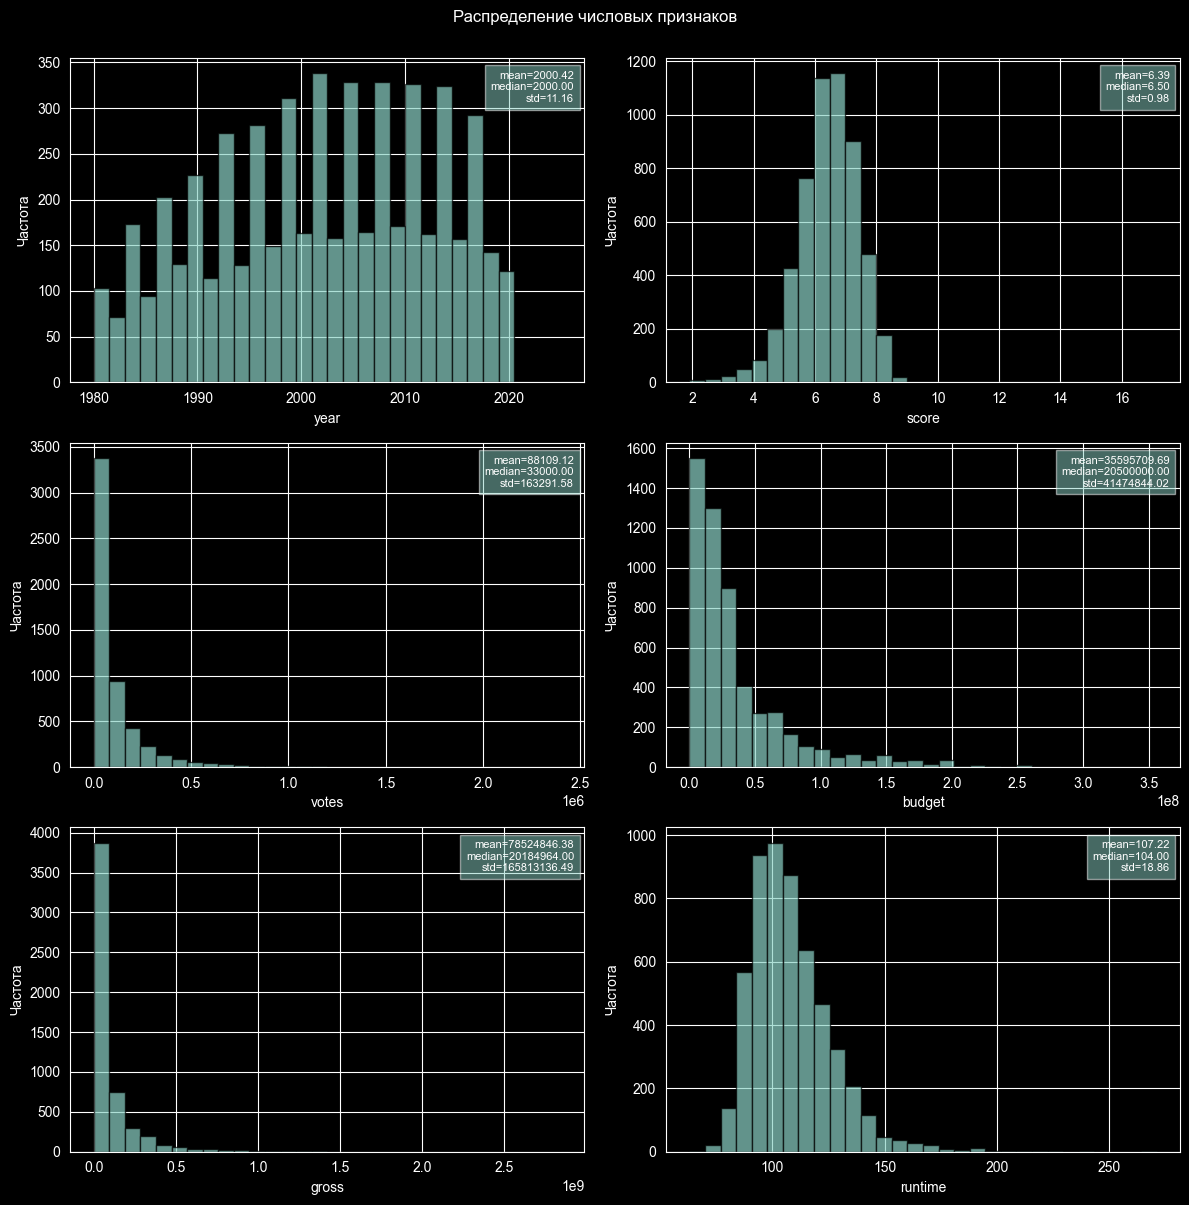

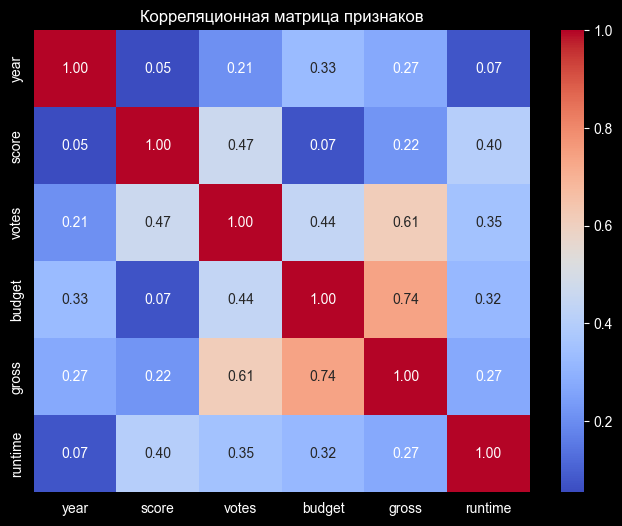

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(df_num):
    axes[i].hist(df_num[col], bins=30, edgecolor='k', alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

    mean_val = df[col].dropna().mean()
    median_val = df[col].dropna().median()
    std_val = df[col].dropna().std()
    stats_text = f"mean={mean_val:.2f}\nmedian={median_val:.2f}\nstd={std_val:.2f}"

    axes[i].text(0.98, 0.96, stats_text, transform=axes[i].transAxes,
        verticalalignment='top', horizontalalignment='right',
        fontsize=8, bbox=dict(alpha=0.5))

plt.suptitle('Распределение числовых признаков', y=1)
plt.tight_layout()
plt.show()

# Матрица корреляций
plt.figure(figsize=(8,6))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

**1. Есть ли сильно коррелированные признаки?**
Да, в представленной корреляционной матрице есть пара с заметной корреляцией:
- `budget` и `gross` – коэффициент 0.74 (сильная положительная корреляция).

Так же есть несколько пар с умеренной корреляцией:
- `votes` и `gross` – 0.61
- `votes` и `budget` – 0.44
- `score` и `votes` – 0.47
- `score` и `runtime` – 0.40

Остальные пары имеют слабую корреляцию.

**2. Можно ли предположить, что часть признаков содержит избыточную информацию?**
Да, можно. В частности, признаки `budget` и `gross` сильно связаны между собой – они во многом описывают «масштаб» фильма, и один из них может быть частично избыточен. Также `votes` (количество голосов) коррелирует и с бюджетом, и со сборами, и с рейтингом – возможно, он отражает общую популярность фильма, которая уже частично заложена в других признаках.


## Задание 2. Реализация PCA


Сравнение с sklearn
Корреляция PC1: 1.000000
Корреляция PC2: 1.000000
Результаты совпадают (с точностью до знака)

Доля объясненной дисперсии:
  PC1: 45.4% (накоплено: 45.4%)
  PC2: 20.3% (накоплено: 65.6%)
  PC3: 13.4% (накоплено: 79.0%)
  PC4: 11.3% (накоплено: 90.3%)
  PC5: 6.2% (накоплено: 96.5%)
  PC6: 3.5% (накоплено: 100.0%)


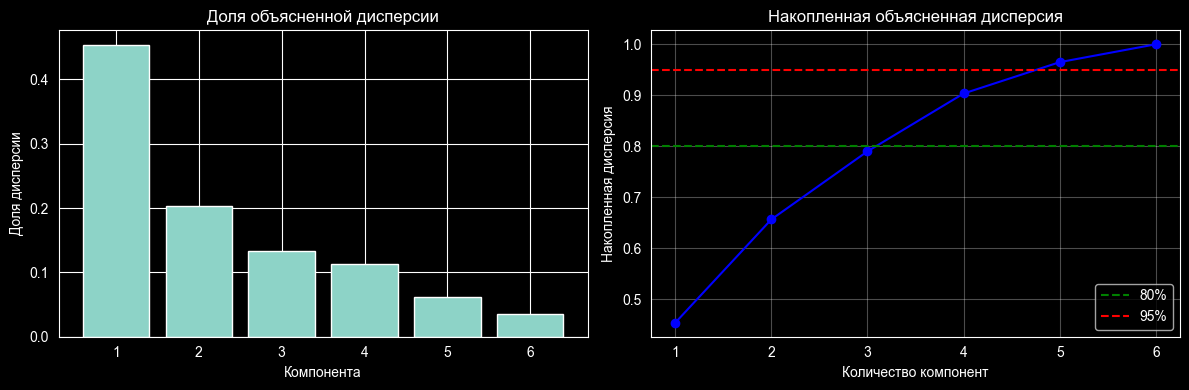


   4 компонент(ы) объясняют 80% дисперсии (90.3%)
   5 компонент(ы) объясняют 95% дисперсии (96.5%)


In [11]:
X = df_num.values
# 1. Стандартизация
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

# 2. Ковариационная матрица
cov_matrix = np.cov(X_std.T)

# 3. Собственные значения и векторы
eigenvals, eigenvecs = np.linalg.eig(cov_matrix)
eigenvals, eigenvecs = np.real(eigenvals), np.real(eigenvecs)

# 4. Сортировка
idx = np.argsort(eigenvals)[::-1]
eigenvals_sorted = eigenvals[idx]
eigenvecs_sorted = eigenvecs[:, idx]

# Доля объясненной дисперсии
explained_var = eigenvals_sorted / np.sum(eigenvals_sorted)
cumulative_var = np.cumsum(explained_var)

# 5. Проекция на k компонент
def pca_project(X, eigenvectors, k):
    return X @ eigenvectors[:, :k]
# Проверка корреляции с sklearn
pca_sklearn = PCA()
X_pca_sklearn = pca_sklearn.fit_transform(X_std)

print("\nСравнение с sklearn")
X_my = pca_project(X_std, eigenvecs_sorted, 2)
corr1 = np.corrcoef(X_my[:, 0], X_pca_sklearn[:, 0])[0, 1]
corr2 = np.corrcoef(X_my[:, 1], X_pca_sklearn[:, 1])[0, 1]
print(f"Корреляция PC1: {abs(corr1):.6f}")
print(f"Корреляция PC2: {abs(corr2):.6f}")
print("Результаты совпадают (с точностью до знака)")

print("\nДоля объясненной дисперсии:")
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"  PC{i}: {ev*100:.1f}% (накоплено: {cv*100:.1f}%)")

# Графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, len(explained_var)+1), explained_var)
ax1.set_xlabel('Компонента')
ax1.set_ylabel('Доля дисперсии')
ax1.set_title('Доля объясненной дисперсии')

ax2.plot(range(1, len(cumulative_var)+1), cumulative_var, 'bo-')
ax2.axhline(y=0.8, color='g', linestyle='--', label='80%')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95%')
ax2.set_xlabel('Количество компонент')
ax2.set_ylabel('Накопленная дисперсия')
ax2.set_title('Накопленная объясненная дисперсия')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ответы на вопросы
n_80 = np.argmax(cumulative_var >= 0.8) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f"\n   {n_80} компонент(ы) объясняют 80% дисперсии ({cumulative_var[n_80-1]*100:.1f}%)")
print(f"   {n_95} компонент(ы) объясняют 95% дисперсии ({cumulative_var[n_95-1]*100:.1f}%)")


## Задание 3. Интерпретация главных компонент

      КОЭФФИЦИЕНТЫ ПРИЗНАКОВ
           PC1    PC2    PC3
year    -0.253 -0.440 -0.851
score   -0.306  0.635 -0.318
votes   -0.487  0.155  0.042
budget  -0.470 -0.379  0.289
gross   -0.511 -0.247  0.299
runtime -0.351  0.418  0.010


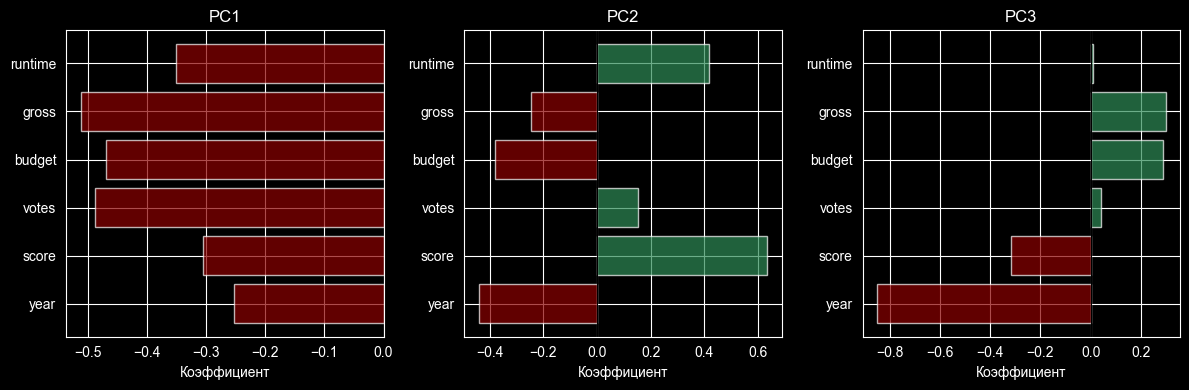

Признаки с наибольшим вкладом

PC1:
   Максимальный вклад: gross = -0.511
   Топ-3: gross(-0.511), votes(-0.487), budget(-0.470)
PC2:
   Максимальный вклад: score = 0.635
   Топ-3: score(+0.635), year(-0.440), runtime(+0.418)
PC3:
   Максимальный вклад: year = -0.851
   Топ-3: year(-0.851), score(-0.318), gross(+0.299)


In [12]:
features = df_num.columns
# Коэффициенты первых трёх компонент
loadings = pd.DataFrame(
    eigenvecs_sorted[:, :3],
    columns=['PC1', 'PC2', 'PC3'],
    index=features
)

print("      КОЭФФИЦИЕНТЫ ПРИЗНАКОВ")
print(loadings.round(3))

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    values = loadings.iloc[:, i].values
    colors = ['darkred' if v < 0 else 'seagreen' for v in values]
    ax.barh(features, values, color=colors, alpha=0.7)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(f'PC{i+1}')
    ax.set_xlabel('Коэффициент')
plt.tight_layout()
plt.show()

print("Признаки с наибольшим вкладом\n")
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"{pc}:")
    # максимальный по модулю коэффициент
    max_idx = loadings[pc].abs().idxmax()
    max_val = loadings.loc[max_idx, pc]
    print(f"   Максимальный вклад: {max_idx} = {max_val:.3f}")
    # топ-3
    top3 = loadings[pc].abs().sort_values(ascending=False).head(3)
    print(f"   Топ-3: {', '.join([f'{idx}({loadings.loc[idx, pc]:+.3f})' for idx in top3.index])}")


1. **Какие признаки больше всего влияют на первую компоненту?**
   Наибольшее влияние на первую главную компоненту оказывают признаки `gross` (коэффициент –0.511), `votes` (–0.487), `budget` (–0.470) и `runtime` (–0.351). Все перечисленные признаки имеют высокий по модулю вклад (более 0.35), причём сборы, количество голосов и бюджет являются доминирующими.

2. **Можно ли интерпретировать первую компоненту как некоторую комбинацию исходных признаков?**
   Да. Первая компонента представляет собой линейную комбинацию исходных признаков:
   **PC1 ≈ –0.47·budget – 0.51·gross – 0.49·votes – 0.35·runtime + (вклад остальных признаков)** PC1 отражает обобщённый **«размер фильма»**: чем выше бюджет, сборы, популярность(votes) и длительность, тем ниже значение PC1. Поэтому первую компоненту можно интерпретировать как **«коммерческий масштаб и успешность фильма»**.

3. **Есть ли признаки, которые практически не влияют на первые три компоненты?**
   В данном наборе данных все шесть признаков вносят заметный вклад в первые три главные компоненты. Ни один из признаков не имеет максимального коэффициента (по модулю) меньше 0.2. Наименьшее относительное влияние среди всех признаков наблюдается у `runtime` (его максимальный коэффициент в PC1–PC3 составляет 0.418, что всё ещё значительно). Таким образом, все признаки информативны, и исключение любого из них приведёт к потере части дисперсии.

## Задание 4. Визуализация данных

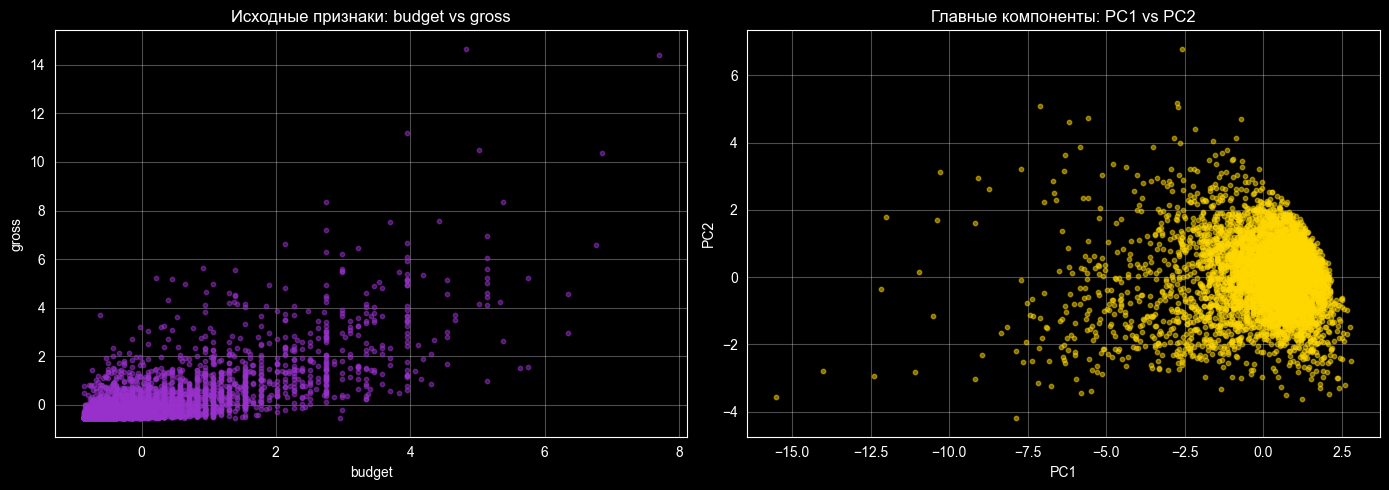

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
X_pca = pca_project(X_std, eigenvecs_sorted, 2)

idx_budget = features.get_loc('budget')
idx_gross = features.get_loc('gross')
ax1.scatter(X_std[:, idx_budget], X_std[:, idx_gross], alpha=0.5, s=10, c='darkorchid')
ax1.set_xlabel('budget')
ax1.set_ylabel('gross')
ax1.set_title('Исходные признаки: budget vs gross')
ax1.grid(True, alpha=0.3)

ax2.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=10, c='gold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('Главные компоненты: PC1 vs PC2')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Сравнение структуры распределения

**Исходные признаки (`budget` vs `gross`):**
- Точки сильно вытянуты вдоль диагонали.
- Основная масса объектов сконцентрирована вблизи нуля.
- Присутствуют выбросы – фильмы с экстремально высокими бюджетом и сборами.
- Из-за сильной линейной связи выделить визуальные группы или кластеры практически невозможно.

**Главные компоненты (PC1 vs PC2):**
- Данные «развёрнуты»: PC1 направлена вдоль максимальной изменчивости (коммерческий масштаб), PC2 ортогональна и отражает качество (score) и продолжительность.
- Облако точек стало более округлым, равномерно распределённым.
- Проявляются потенциальные кластеры (например, отдельные сгущения могут соответствовать разным уровням успеха).
- Выбросы выделяются отчётливее.



### Ответы на вопросы

1. **Улучшилась ли визуализация после PCA?**
   **ДА.** В исходных признаках (`budget`, `gross`) точки сжаты вдоль узкой диагонали из-за высокой корреляции. PCA максимизировать дисперсию – данные становятся «развёрнутыми», что облегчает визуальный анализ.

2. **Почему в пространстве главных компонент структура может быть заметнее?**
   - PC1 ориентирована вдоль направления **максимальной дисперсии** (коммерческий масштаб: бюджет, сборы, голоса).
   - PC2 ортогональна PC1 и показывает **второе по важности направление** (рейтинг и год выпуска).
   - Шум и малозначимые вариации подавляются, так как они сосредоточены в младших компонентах (PC3–PC6), которые не используются в визуализации.

## Задание 5. Нелинейные методы снижения размерности

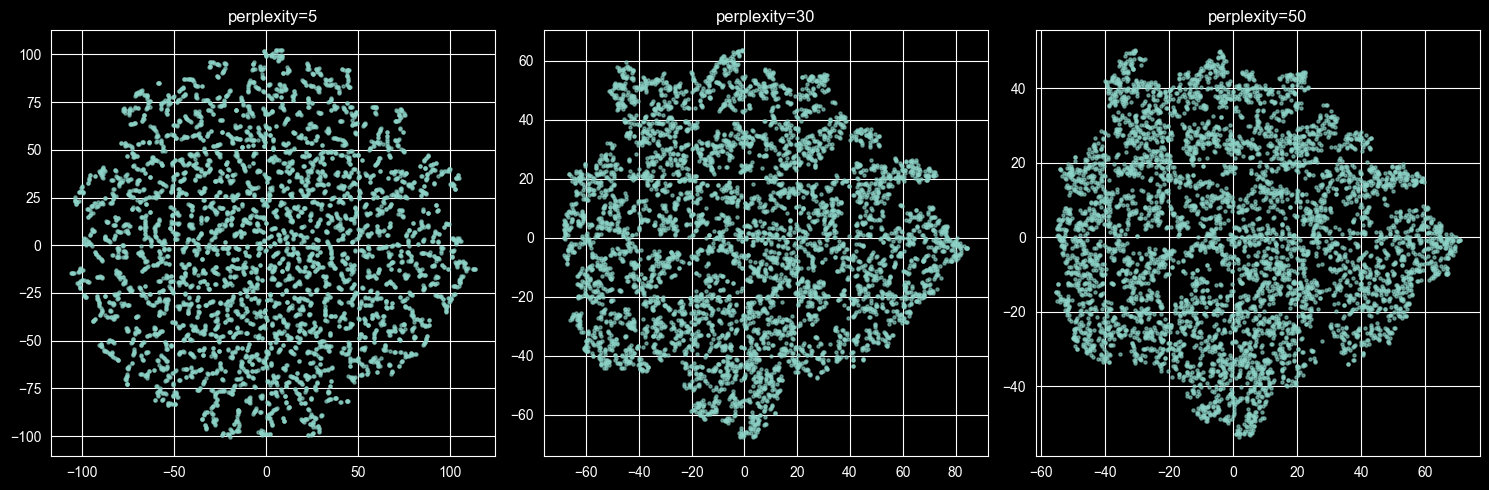

C:\Users\Admin\PycharmProjects\lab1_iad\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Admin\PycharmProjects\lab1_iad\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Admin\PycharmProjects\lab1_iad\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


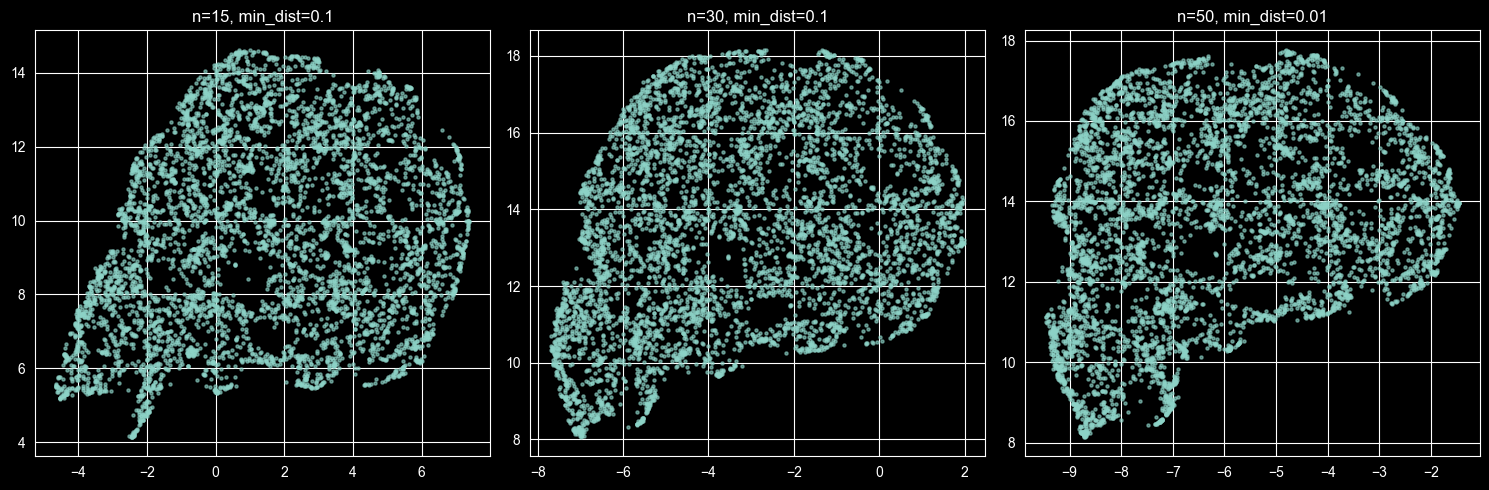

In [14]:
X_sample = X_std

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
perplexities = [5, 30, 50]
for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=112, max_iter=1000)
    X_tsne = tsne.fit_transform(X_sample)
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], s=5, alpha=0.6)
    axes[i].set_title(f'perplexity={perp}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
umap_params = [(15, 0.1), (30, 0.1), (50, 0.01)]
for i, (n, d) in enumerate(umap_params):
    reducer = umap.UMAP(n_neighbors=n, min_dist=d, random_state=112)
    X_umap = reducer.fit_transform(X_sample)
    axes[i].scatter(X_umap[:, 0], X_umap[:, 1], s=5, alpha=0.6)
    axes[i].set_title(f'n={n}, min_dist={d}')
plt.tight_layout()
plt.show()

**1. Как меняется структура данных при разных параметрах?**
- **t‑SNE:**
  *Perplexity=5* – множество мелких изолированных кластеров, сильный разброс (‑100…100).
  *Perplexity=30* – компактная проекция (‑60…60), чёткие кластеры, баланс локального/глобального.
  *Perplexity=50* – кластеры сглажены, границы размыты, глобальная структура выражена лучше.
- **UMAP:**
  *n=15, min_dist=0.1* – плотные, хорошо разделённые кластеры.
  *n=30, min_dist=0.5* – кластеры рыхлые, видны переходы между группами.
  *n=50, min_dist=0.01* – очень плотные микро-кластеры, глобальная структура искажена.

**2. Какой метод даёт наиболее интерпретируемую визуализацию?**
**t‑SNE с perplexity=30** – даёт чёткие, компактные кластеры, легко выделяются группы фильмов по масштабу (бюджет/сборы) и качеству (рейтинг). UMAP при (15,0.1) тоже хорош, но часто создаёт менее привычные формы кластеров.

**3. Почему результаты разных методов могут существенно отличаться?**
- Разные функции потерь: t‑SNE использует **асимметричную KL-дивергенцию** (фокус на локальной структуре), UMAP – **симметричную кросс-энтропию** (сохраняет и глобальную топологию).
- t‑SNE может произвольно разносить далёкие кластеры, UMAP старается сохранить расстояния между ними.
- Разная чувствительность к параметрам и выбросам.

## Задание 6. Исследование степени сжатия данных

Число компонент | Ошибка восстановления (MSE)
---------------------------------------------
       2        | 0.343588
       3        | 0.210012
       4        | 0.096555
       5        | 0.035047
       6        | 0.000000


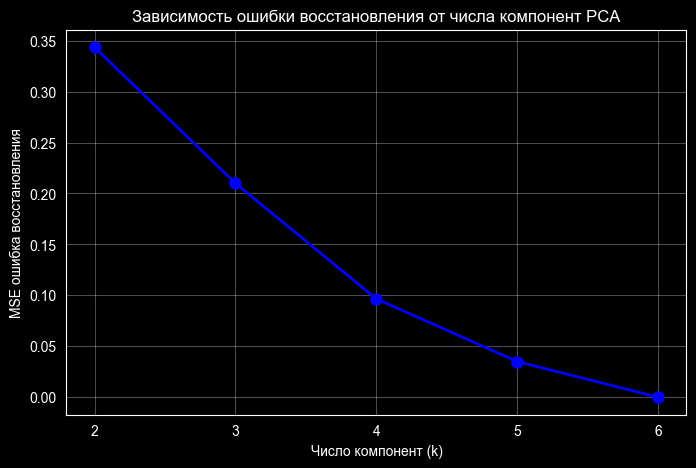

In [15]:
k_values = [2, 3, 4, 5, 6]  # только 6 признаков
results = []
mse_values = []

for k in k_values:
    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X_std)
    X_reconstructed = pca.inverse_transform(X_reduced)
    mse = np.mean((X_std - X_reconstructed) ** 2)
    mse_values.append(mse)
    results.append([k, mse])


print("Число компонент | Ошибка восстановления (MSE)")
print("---------------------------------------------")
for k, mse in results:
    print(f"{k:^15} | {mse:.6f}")


# График
plt.figure(figsize=(8, 5))
plt.plot(k_values, mse_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число компонент (k)')
plt.ylabel('MSE ошибка восстановления')
plt.title('Зависимость ошибки восстановления от числа компонент PCA')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()



**Анализ формы графика:**

- Ошибка восстановления **резко уменьшается** при увеличении числа компонент с 2 до 4 (с 0.344 до 0.097, снижение более чем в 3.5 раза).
- При добавлении 5-й компоненты ошибка снижается уже не так сильно (с 0.097 до 0.035).
- 6-я компонента даёт нулевую ошибку, но при этом размерность не уменьшается (полное восстановление).

Существует значение k ≈ 4–5, после которого уменьшение ошибки становится незначительным. Дальнейшее увеличение числа компонент даёт лишь малый выигрыш в точности, но требует больше

1. **Почему при малом числе компонент ошибка восстановления большая?**
   Потому что мы отбрасываем компоненты с малой дисперсией, а вместе с ними теряется информация. При k=2 сохраняется лишь 65.6% дисперсии, остальные 34.4% (существенная часть) теряются → высокая ошибка (0.344).

2. **Почему увеличение числа компонент уменьшает ошибку?**
   Каждая добавленная компонента возвращает часть утерянной дисперсии. С каждой новой компонентой восстановленные данные становятся ближе к исходным, поэтому MSE монотонно убывает (с 0.344 → 0.210 → 0.097 → 0.035 → 0.000).

3. **Можно ли полностью восстановить исходные данные при использовании всех компонент?**
   Да. При k = числу исходных признаков (6) PCA становится просто поворотом системы координат без потери информации. MSE = 0 (с точностью до вычислительных погрешностей), что и подтверждают результаты.

4. **Как это связано с объяснённой дисперсией PCA?**
   MSE = 1 − (накопленная доля объяснённой дисперсии) при стандартизованных данных. Чем больше дисперсии сохраняется, тем меньше ошибка. Например:
   - k=2: дисперсия 65.6% → ошибка 0.344
   - k=5: дисперсия 96.5% → ошибка 0.035
   - k=6: дисперсия 100% → ошибка 0


5. **Как определить разумное число компонент?**
   По графику зависимости MSE от k (или накопленной дисперсии) ищут точку, после которой уменьшение ошибки становится незначительным. В нашем случае это k=4 (ошибка 0.097, дисперсия 90.3%) или k=5 (ошибка 0.035, дисперсия 96.5%). Выбор зависит от допустимой потери точности: для грубого сжатия достаточно 4 компонент, для более точного – 5.

## Задание 7. Итоговый анализ


1. **Какую роль играет снижение размерности в анализе данных?**
   Позволяет визуализировать многомерные данные (например, проецируя на 2D или 3D), уменьшает вычислительную сложность, устраняет мультиколлинеарность и шум, помогает выявлять скрытые закономерности и кластеры.

2. **Всегда ли уменьшение размерности полезно?**
   Нет. При слишком сильном сжатии теряется важная информация (ошибка восстановления растёт). Некоторые алгоритмы (деревья решений, случайный лес) не требуют снижения размерности. Также интерпретация компонент может быть сложной.

3. **В каких случаях линейные методы могут работать хуже нелинейных?**
   Когда данные лежат на нелинейном многообразии (изогнутые поверхности, разрывы, свертки). Например, в наших данных PCA выделил только глобальную структуру (масштаб+качество), а t‑SNE и UMAP могут показать локальные кластеры по жанрам или годам, которые не видны в линейной проекции.

4. **Преимущества и ограничения методов:**

| Метод | Преимущества | Ограничения |
|-------|--------------|--------------|
| **PCA** | Быстрый, детерминированный, легко интерпретировать компоненты (вклады признаков), позволяет восстановить данные. | Только линейные зависимости, не выявляет сложные локальные структуры. |
| **t‑SNE** | Отлично показывает локальные кластеры, популярен для визуализации. | Очень медленный на больших данных (требует подвыборки), не сохраняет глобальные расстояния, стохастичен, сильно зависит от perplexity. |
| **UMAP** | Быстрее t‑SNE, лучше сохраняет глобальную структуру, работает с большими данными, устойчивее к выбору параметров. | Интерпретация осей отсутствует, параметры (n_neighbors, min_dist) всё же нужно подбирать, стохастичен. |